# OTA Dataset Preprocessing & Filtering

Use this notebook to explore UAV captures, tune burst thresholds, and export datasets compatible with `TPrime_transformer_train.py`.

## Workflow
1. Edit the **Global Configuration** cell below.
2. Run the **Threshold Preview** cell repeatedly while adjusting thresholds/config values.
3. Once satisfied, set `SAVE_DATASET = True` and execute the **Run Preprocessing** cell to emit `_train` / `_eval` folders.


In [ ]:
from pathlib import Path

# --- Global Configuration -------------------------------------------------
SRC_ROOT = Path('/mnt/dm-3/DroneDetect/DroneDetect_V2')
CONDITION = 'CLEAN'             # {'BLUE','WIFI','BOTH','CLEAN'}
MODE = 'HO'                     # {'ON','HO','FY'}
FS = 60e6                       # Sampling rate (Hz)
SAMPLES_PER_FILE = 37740         # Complex samples per saved slice
NUM_EXAMPLES_PER_CLASS = 1000    # Training slices per class
EVAL_RATIO = 0.1                # Portion of slices reserved for eval set
OUT_ROOT = Path('../data')
DATASET_NAME = 'CLEAN_HO_timePulseExtraction'
SAVE_DATASET = True            # True => export dataset, False => preview only
ENABLE_PLOTTING = True          # Show diagnostics during processing
PREPROCESS_OPTION = 'time_only' # {'time_only','time_freq'}
TIME_POWER_THRESHOLD = None     # Absolute time-domain threshold (None -> percentile)
TIME_PERCENTILE = 99.0          # Percentile used when TIME_POWER_THRESHOLD is None
FREQ_POWER_THRESHOLD = None     # Absolute freq-domain threshold (None -> percentile)
FREQ_PERCENTILE = 98.0          # Percentile used when FREQ_POWER_THRESHOLD is None
MIN_BURST_LEN = 2048            # Minimum burst length to keep (samples)
BANDPASS_HZ = (5e6, 25e6)       # Only used when PREPROCESS_OPTION == 'time_freq'
DOWNSAMPLE = 2                  # >=1
FREQ_SHIFT_HZ = 0.0             # Center bursts (Hz)
IGNORE_DC = True                # Suppress selections near DC
DC_IGNORE_BW = 200e3              # Width (Hz) around 0 to ignore when IGNORE_DC=True
PREVIEW_CLASS = 'AIR'
PREVIEW_FILE_INDEX = 0
PREVIEW_MAX_SEGMENTS = 5
RANDOM_SEED = 4389


In [55]:
from dataclasses import dataclass
from typing import Dict, List, Sequence, Tuple, Optional
import math
import shutil
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
from scipy import signal
from tqdm.notebook import tqdm

plt.rcParams['figure.figsize'] = (12, 4)
np.random.seed(RANDOM_SEED)

SUPPORTED_EXT = {'.dat', '.bin', '.mat'}
VALID_CONDITIONS = {'BLUE','WIFI','BOTH','CLEAN'}
VALID_MODES = {'ON','HO','FY'}
PREPROCESS_OPTIONS = {'time_only','time_freq'}

@dataclass
class Segment:
    data: np.ndarray
    src_path: Path
    start: int
    end: int


def validate_config():
    assert CONDITION.upper() in VALID_CONDITIONS
    assert MODE.upper() in VALID_MODES
    assert PREPROCESS_OPTION in PREPROCESS_OPTIONS
    assert SAMPLES_PER_FILE > 0
    assert FS > 0
    assert NUM_EXAMPLES_PER_CLASS > 0
    assert DOWNSAMPLE >= 1


def load_waveform(path: Path, waveform_key: str = 'waveform') -> np.ndarray:
    path = Path(path)
    ext = path.suffix.lower()
    if ext == '.dat':
        raw = np.fromfile(path, dtype=np.float32)
        usable = (raw.size // 2) * 2
        if usable == 0:
            raise ValueError(f"{path} has no IQ samples")
        return raw[:usable].view(np.complex64)
    if ext == '.bin':
        return np.fromfile(path, dtype=np.complex128)
    if ext == '.mat':
        mat = loadmat(path)
        if 'waveform' not in mat:
            raise KeyError(f"'waveform' key missing in {path}")
        data = mat['waveform']
        if data.ndim > 1:
            data = data.squeeze()
        return np.asarray(data).astype(np.complex64)
    raise ValueError(f"Unsupported extension: {ext}")


def gather_class_files(src_root: Path, condition: str, mode: str) -> Dict[str, List[Path]]:
    cond_dir = src_root / condition.upper()
    if not cond_dir.is_dir():
        raise FileNotFoundError(f"Condition folder {cond_dir} not found")
    suffix = f"_{mode.upper()}"
    file_map: Dict[str, List[Path]] = {}
    for subdir in sorted(cond_dir.rglob('*')):
        if not subdir.is_dir():
            continue
        name = subdir.name.upper()
        if not name.endswith(suffix):
            continue
        class_name = subdir.name[: -len(suffix)].rstrip('_')
        files = [f for f in sorted(subdir.glob('*')) if f.suffix.lower() in SUPPORTED_EXT]
        if files:
            file_map.setdefault(class_name, []).extend(files)
    if not file_map:
        raise RuntimeError(f"No files found under {cond_dir} for mode {mode}")
    return file_map


def magnitude_power(x: np.ndarray) -> np.ndarray:
    return np.abs(x) ** 2


def suggest_threshold(values: np.ndarray, percentile: float) -> float:
    return float(np.percentile(values, percentile))


def find_bursts(power: np.ndarray, threshold: float, min_len: int) -> List[Tuple[int,int]]:
    mask = power >= threshold
    edges = np.diff(mask.astype(int), prepend=0, append=0)
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]
    bursts = []
    for s, e in zip(starts, ends):
        if e - s >= min_len:
            bursts.append((s, e))
    return bursts


def apply_bandpass(samples: np.ndarray, fs: float, band: Tuple[float,float]) -> np.ndarray:
    nyq = fs / 2
    low_hz, high_hz = band
    center = 0.5 * (low_hz + high_hz)
    half_bw = 0.5 * (high_hz - low_hz) * 1.5  # widen by 1.5x
    low_hz = max(0.0, center - half_bw)
    high_hz = min(nyq, center + half_bw)
    low = low_hz / nyq
    high = high_hz / nyq
    if not (0 < low < high < 1):
        raise ValueError("BANDPASS_HZ must be within (0, fs/2)")
    taps = signal.firwin(513, [low, high], pass_zero=False)
    return signal.lfilter(taps, 1.0, samples)


def freq_shift(samples: np.ndarray, fs: float, shift_hz: float) -> np.ndarray:
    if shift_hz == 0:
        return samples
    n = np.arange(samples.size)
    return samples * np.exp(-2j * np.pi * shift_hz * n / fs)


def downsample(samples: np.ndarray, factor: int) -> np.ndarray:
    if factor == 1:
        return samples
    return signal.decimate(samples, factor, ftype='fir', zero_phase=True)


def contiguous_intervals(freqs: np.ndarray, mask: np.ndarray) -> List[Tuple[float,float]]:
    intervals = []
    start = None
    for f, m in zip(freqs, mask):
        if m and start is None:
            start = f
        elif not m and start is not None:
            intervals.append((start, prev))
            start = None
        prev = f
    if start is not None:
        intervals.append((start, freqs[-1]))
    return intervals


def suppress_dc(intervals: List[Tuple[float,float]], ignore_dc: bool, bw: float) -> List[Tuple[float,float]]:
    if not ignore_dc:
        return intervals
    cleaned = []
    half_bw = bw / 2
    for f_start, f_end in intervals:
        if f_start <= 0 <= f_end:
            if (f_end - f_start) < bw:
                continue
            if abs(f_start) < half_bw:
                f_start = -half_bw
            if abs(f_end) < half_bw:
                f_end = half_bw
        cleaned.append((f_start, f_end))
    return cleaned


def save_segment(seg: Segment, dest_dir: Path, class_name: str, idx: int):
    class_dir = dest_dir / class_name
    class_dir.mkdir(parents=True, exist_ok=True)
    fname = f"{seg.src_path.stem}__idx{idx:05d}__s{seg.start}_e{seg.end}.mat"
    savemat(class_dir / fname, {'waveform': seg.data[:, None]}, do_compression=False)


def slice_burst_windows(start: int, end: int, wave_len: int, samples_per_file: int, stride: Optional[int] = None) -> List[Tuple[int, int]]:
    if wave_len <= samples_per_file:
        return [(0, wave_len)]
    stride = stride if stride not in (None, 0) else max(1, samples_per_file // 2)
    segs = []
    length = end - start
    if length <= 0:
        return segs
    if length <= samples_per_file:
        center = (start + end) // 2
        s = max(0, min(center - samples_per_file // 2, wave_len - samples_per_file))
        segs.append((s, s + samples_per_file))
        return segs
    s = start
    while s < end:
        e = s + samples_per_file
        if e > wave_len:
            e = wave_len
            s = e - samples_per_file
        segs.append((s, e))
        s += stride
    return segs



### Threshold Preview

Using config -> FS=60.0 MHz, slice=37740 samples, preprocess=time_freq, downsample=2, bandpass=(5000000.0, 25000000.0)
Selected file: /mnt/dm-3/DroneDetect/DroneDetect_V2/CLEAN/AIR_HO/AIR_0001_00.dat
Time threshold: 1.149e-01
Freq threshold base: percentile 98.0


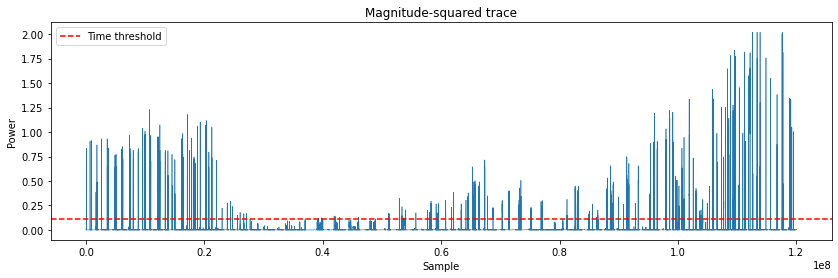

Detected 1200007 samples above threshold; preview will show up to 5 windows (~37740 samples each).


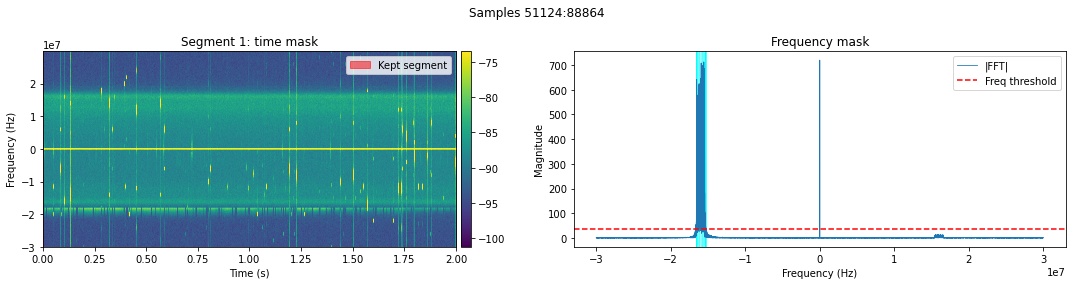

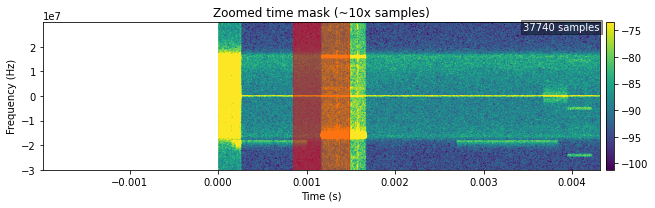

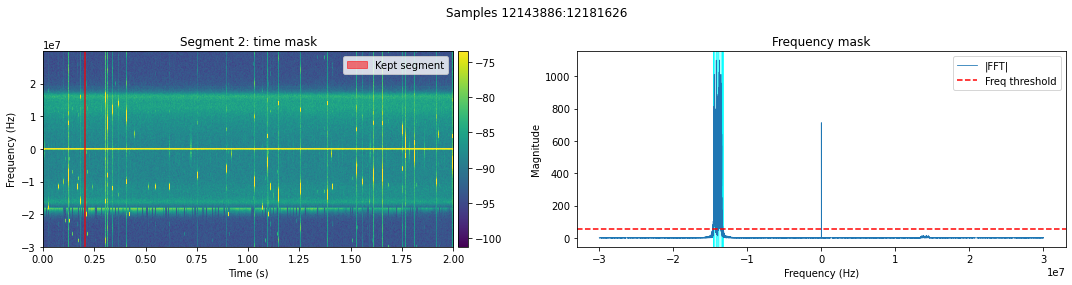

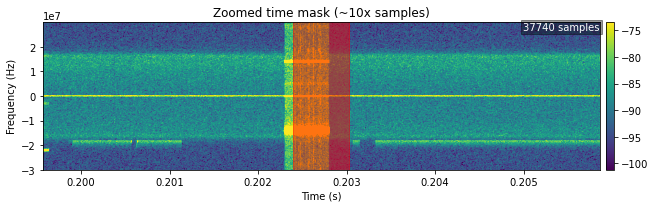

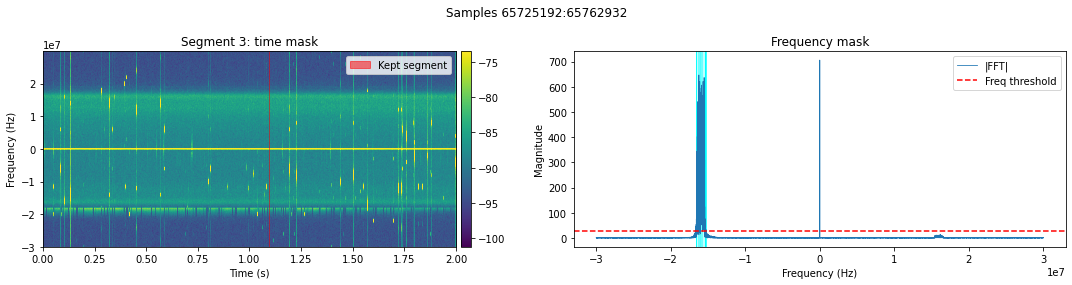

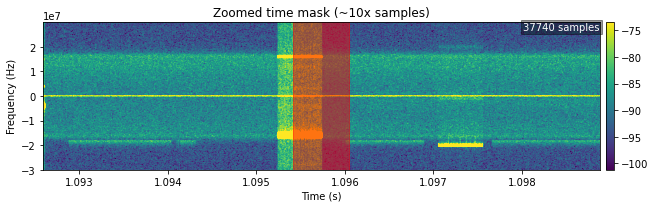

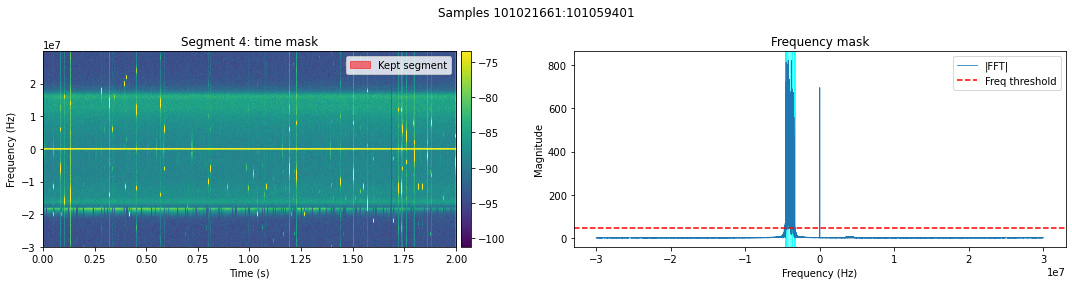

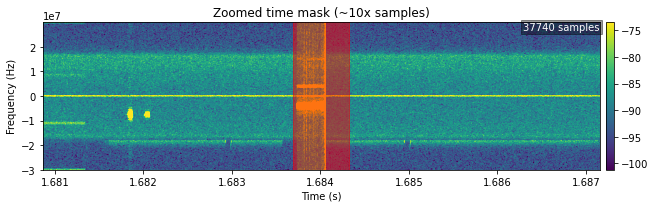

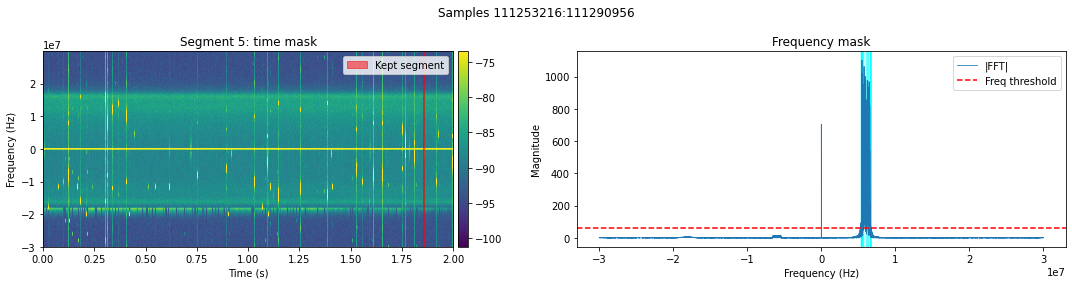

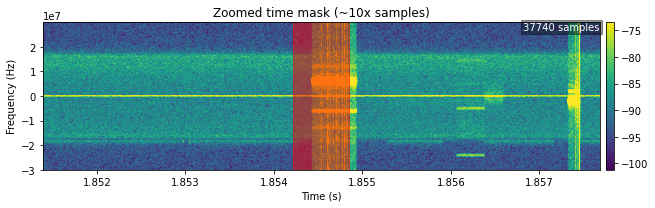

In [56]:
validate_config()
print(f"Using config -> FS={FS/1e6:.1f} MHz, slice={SAMPLES_PER_FILE} samples, preprocess={PREPROCESS_OPTION}, downsample={DOWNSAMPLE}, bandpass={BANDPASS_HZ}")
file_map = gather_class_files(SRC_ROOT, CONDITION, MODE)
if PREVIEW_CLASS not in file_map:
    raise ValueError(f"Class '{PREVIEW_CLASS}' not found. Available: {sorted(file_map.keys())}")
files = file_map[PREVIEW_CLASS]
if PREVIEW_FILE_INDEX >= len(files):
    raise IndexError(f"PREVIEW_FILE_INDEX {PREVIEW_FILE_INDEX} >= {len(files)}")
preview_path = files[PREVIEW_FILE_INDEX]
wave = load_waveform(preview_path)
power = magnitude_power(wave)

# thresholds
time_thresh = TIME_POWER_THRESHOLD or suggest_threshold(power, TIME_PERCENTILE)
freq_thresh_global = FREQ_POWER_THRESHOLD
print(f"Selected file: {preview_path}")
print(f"Time threshold: {time_thresh:.3e}")
print(f"Freq threshold base: {freq_thresh_global if freq_thresh_global else f'percentile {FREQ_PERCENTILE}'}")

plt.figure(figsize=(14,4))
plt.plot(power, linewidth=0.6)
plt.axhline(time_thresh, color='r', linestyle='--', label='Time threshold')
plt.legend(); plt.title('Magnitude-squared trace'); plt.xlabel('Sample'); plt.ylabel('Power'); plt.show()

segments = []
wave_len = wave.size
bursts = find_bursts(power, time_thresh, 1)
print(f"Detected {len(bursts)} threshold crossings; preview will show up to {PREVIEW_MAX_SEGMENTS} windows (~{SAMPLES_PER_FILE} samples each).")

if not bursts:
    print('[WARN] No samples crossed the time threshold; consider lowering TIME_POWER_THRESHOLD.')
else:
    stride = max(1, len(bursts) // PREVIEW_MAX_SEGMENTS)
    for start, end in bursts[::stride][:PREVIEW_MAX_SEGMENTS]:
        segments.extend(slice_burst_windows(start, end, wave_len, SAMPLES_PER_FILE))

# Deduplicate while preserving order and limit to preview max
seen = set()
unique_segments = []
for seg in segments:
    if seg not in seen:
        unique_segments.append(seg)
        seen.add(seg)
    if len(unique_segments) >= PREVIEW_MAX_SEGMENTS:
        break
segments = unique_segments

if not segments:
    print('No segments exceeded the threshold. Adjust TIME_POWER_THRESHOLD / TIME_PERCENTILE.')
else:
    freqs, times, Zxx = signal.stft(wave, fs=FS, nperseg=1024, noverlap=768, return_onesided=False)
    freqs = np.fft.fftshift(freqs)
    Zxx = np.fft.fftshift(Zxx, axes=0)
    power_db = 20 * np.log10(np.abs(Zxx) + 1e-9)
    vmin, vmax = np.percentile(power_db, [5, 99])
    freq_axis = np.fft.fftshift(np.fft.fftfreq(SAMPLES_PER_FILE, d=1/FS))
    shared_kwargs = dict(aspect='auto', origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
    for idx, (start, end) in enumerate(segments, 1):
        segment = wave[start:end]
        seg_spec = np.abs(np.fft.fftshift(np.fft.fft(segment)))
        freq_thresh = freq_thresh_global or suggest_threshold(seg_spec, FREQ_PERCENTILE)
        mask = seg_spec >= freq_thresh
        intervals = suppress_dc(contiguous_intervals(freq_axis, mask), IGNORE_DC, DC_IGNORE_BW)
        fig, axes = plt.subplots(1, 2, figsize=(15,4))
        im = axes[0].imshow(power_db, extent=(times[0], times[-1], freqs[0], freqs[-1]), **shared_kwargs)
        axes[0].axvspan(start/FS, end/FS, color='red', alpha=0.5, label='Kept segment')
        axes[0].set_title(f'Segment {idx}: time mask'); axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Frequency (Hz)')
        axes[0].legend(loc='upper right')
        plt.colorbar(im, ax=axes[0], pad=0.01)
        axes[1].plot(freq_axis, seg_spec, linewidth=0.8, label='|FFT|')
        axes[1].axhline(freq_thresh, color='r', linestyle='--', label='Freq threshold')
        for f_start, f_end in intervals:
            axes[1].axvspan(f_start, f_end, color='cyan', alpha=0.25)
        axes[1].set_title('Frequency mask'); axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('Magnitude')
        axes[1].legend()
        plt.suptitle(f"Samples {start}:{end}")
        plt.tight_layout()
        plt.show()

        window_seconds = (10 * SAMPLES_PER_FILE) / FS
        zoom_half = window_seconds / 2.0
        t_mid = (start + end) / (2 * FS)
        t_min, t_max = t_mid - zoom_half, t_mid + zoom_half
        fig_zoom, ax_zoom = plt.subplots(figsize=(10,3))
        im_zoom = ax_zoom.imshow(power_db, extent=(times[0], times[-1], freqs[0], freqs[-1]), **shared_kwargs)
        ax_zoom.axvspan(start/FS, end/FS, color='red', alpha=0.5)
        ax_zoom.set_xlim(t_min, t_max)
        ax_zoom.set_title('Zoomed time mask (~10x samples)')
        ax_zoom.set_xlabel('Time (s)'); ax_zoom.set_ylabel('Frequency (Hz)')
        ax_zoom.text(t_max, freqs[-1], f'{SAMPLES_PER_FILE} samples', color='white', ha='right', va='top',
                     bbox=dict(facecolor='black', alpha=0.4, pad=2))
        plt.colorbar(im_zoom, ax=ax_zoom, pad=0.01)
        plt.tight_layout()
        plt.show()


### Processing Helpers

In [57]:
def extract_segments_from_file(
    file_path: Path,
    samples_per_file: int,
    time_threshold: float,
    min_len: int,
    preprocess_option: str,
    fs: float,
    enable_plots: bool = True,
) -> List[Segment]:
    data = load_waveform(file_path)
    power = magnitude_power(data)
    bursts = find_bursts(power, time_threshold, min_len)
    segments: List[Segment] = []
    wave_len = data.size
    stride = max(1, samples_per_file // 2)
    if not bursts:
        peak_ixs = np.where(power >= time_threshold)[0]
        for center in peak_ixs:
            segments.extend(slice_burst_windows(center, center+1, wave_len, samples_per_file))
    for start, end in bursts:
        segments.extend(slice_burst_windows(start, end, wave_len, samples_per_file, stride=stride))
    outputs: List[Segment] = []
    for s, e in segments:
        window = data[s:e]
        processed = window
        if preprocess_option == 'time_freq':
            filtered = apply_bandpass(window, fs=fs, band=BANDPASS_HZ)
            shifted = freq_shift(filtered, fs=fs, shift_hz=FREQ_SHIFT_HZ)
            processed = downsample(shifted, DOWNSAMPLE)
        seg = Segment(processed.astype(np.complex64), file_path, s, e)
        outputs.append(seg)
        if enable_plots:
            fig, axes = plt.subplots(1, 2, figsize=(14,3))
            axes[0].plot(np.arange(len(window))+s, np.abs(window)**2)
            axes[0].axhline(time_threshold, color='r', linestyle='--')
            axes[0].set_title('Time burst power'); axes[0].set_xlabel('Sample'); axes[0].set_ylabel('Power')
            axes[1].specgram(processed, NFFT=512, Fs=fs/DOWNSAMPLE, noverlap=256, cmap='viridis')
            axes[1].set_title('Processed spectrogram'); axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Freq (Hz)')
            plt.suptitle(f"{file_path.name} samples {s}:{e}")
            plt.tight_layout(); plt.show()
    return outputs


def allocate_counts(total: int, n_files: int) -> List[int]:
    if n_files == 0:
        return []
    base = total // n_files
    remainder = total % n_files
    counts = [base] * n_files
    for i in range(remainder):
        counts[i] += 1
    return counts


def process_class(
    class_name: str,
    files: Sequence[Path],
    samples_per_file: int,
    num_train: int,
    num_eval: int,
    time_threshold: float,
    preprocess_option: str,
    fs: float,
    enable_plots: bool = True,
) -> Tuple[List[Segment], List[Segment]]:
    train_counts = allocate_counts(num_train, len(files))
    eval_counts = allocate_counts(num_eval, len(files))
    train_segments: List[Segment] = []
    eval_segments: List[Segment] = []
    for fpath, t_quota, e_quota in tqdm(list(zip(files, train_counts, eval_counts)), desc=f"{class_name}"):
        segments = extract_segments_from_file(
            fpath,
            samples_per_file,
            time_threshold,
            MIN_BURST_LEN,
            preprocess_option,
            fs,
            enable_plots=enable_plots,
        )
        if len(segments) < t_quota + e_quota:
            print(f"[WARN] {fpath.name}: produced {len(segments)} (< {t_quota + e_quota})")
        train_segments.extend(segments[:t_quota])
        eval_segments.extend(segments[t_quota:t_quota + e_quota])
    return train_segments, eval_segments


### Run Preprocessing

In [58]:
if not SAVE_DATASET:
    print('SAVE_DATASET is False. Continue iterating on the preview cell before exporting.')
else:
    print(f"Exporting dataset with config: FS={FS/1e6:.1f} MHz, slice={SAMPLES_PER_FILE}, preprocess={PREPROCESS_OPTION}, bandpass={BANDPASS_HZ}, downsample={DOWNSAMPLE}")
    class_files = gather_class_files(SRC_ROOT, CONDITION, MODE)
    time_threshold = TIME_POWER_THRESHOLD
    if time_threshold is None:
        sample_class = next(iter(class_files))
        sample_wave = load_waveform(class_files[sample_class][0])
        time_threshold = suggest_threshold(magnitude_power(sample_wave), TIME_PERCENTILE)
        print(f"Auto time threshold (percentile {TIME_PERCENTILE}): {time_threshold:.3e}")
    else:
        print(f"Using manual time threshold: {time_threshold:.3e}")
    train_root = OUT_ROOT / f"{DATASET_NAME}_train"
    eval_root = OUT_ROOT / f"{DATASET_NAME}_eval"
    for root in (train_root, eval_root):
        if root.exists():
            print(f"[INFO] Removing existing directory {root}")
            shutil.rmtree(root)
        root.mkdir(parents=True, exist_ok=True)
    eval_per_class = max(1, int(math.ceil(NUM_EXAMPLES_PER_CLASS * EVAL_RATIO)))
    plotting_flag = ENABLE_PLOTTING and not SAVE_DATASET
    summary = {}
    est_needed = NUM_EXAMPLES_PER_CLASS + max(1, int(math.ceil(NUM_EXAMPLES_PER_CLASS * EVAL_RATIO)))
    print(f"Estimating segments per class (~{est_needed} required each)...")
    for cname, files in class_files.items():

        train_segments, eval_segments = process_class(
            cname,
            files,
            SAMPLES_PER_FILE,
            NUM_EXAMPLES_PER_CLASS,
            eval_per_class,
            time_threshold,
            PREPROCESS_OPTION,
            FS,
            enable_plots=plotting_flag,
        )
        summary[cname] = (len(train_segments), len(eval_segments))
        if len(train_segments) < NUM_EXAMPLES_PER_CLASS:
            print(f"[WARN] {cname}: requested {NUM_EXAMPLES_PER_CLASS} train segments but only {len(train_segments)} were generated.")
        if len(eval_segments) < eval_per_class:
            print(f"[WARN] {cname}: requested {eval_per_class} eval segments but only {len(eval_segments)} were generated.")
        for idx, seg in enumerate(train_segments):
            save_segment(seg, train_root, cname, idx)
        for idx, seg in enumerate(eval_segments):
            save_segment(seg, eval_root, cname, idx)
    print('Done. Dataset summary:')
    for cname, (tr, ev) in summary.items():
        print(f"  {cname}: train={tr}, eval={ev}")
    print('Outputs:')
    print(train_root)
    print(eval_root)


SAVE_DATASET is False. Continue iterating on the preview cell before exporting.
